# EDA — Caso 1: California Housing

**Fase A del Taller 1.1 — Análisis Exploratorio y Preprocesamiento**

Objetivo del caso: predecir el **valor medio de la vivienda** (`median_house_value`) en distritos de California a partir de ingresos, edad de la casa, variables demográficas y ubicación geográfica.

En este cuaderno se realiza:

1. Carga y exploración general del dataset.
2. Tratamiento de **valores nulos**.
3. Detección y tratamiento de **outliers**.
4. Análisis de **multicolinealidad** (matriz de correlación + VIF).
5. **Estandarización** de variables numéricas (`StandardScaler`).

El resultado final (`housing_clean.csv` + figuras en `figuras/`) alimenta la Fase B (modelamiento).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
os.makedirs("figuras", exist_ok=True)
print("Imports OK · pandas", pd.__version__)

Imports OK · pandas 3.0.5


In [2]:
df = pd.read_csv("housing.csv")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 20,640 | Columnas: 10


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()
print("\n--- Valores nulos por columna ---")
nulos = df.isna().sum()
print(nulos[nulos > 0])
print(f"\nTotal de celdas nulas: {int(nulos.sum()):,} ({100 * nulos.sum() / df.size:.2f} % del dataset)")

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

--- Valores nulos por columna ---
total_bedrooms    207
dtype: int64

Total de celdas nulas: 207 (0.10 % del dataset)


### Tratamiento de valores nulos

Se detectan **207 valores nulos**, todos en `total_bedrooms` (≈ 1.0 % de las filas).

**Decisión:** eliminación de las filas con nulos (`dropna`). El porcentaje es mínimo, no introduce sesgo relevante y mantiene la consistencia con el script de entrenamiento (`train_model.py`).

In [4]:
df_clean = df.dropna().reset_index(drop=True)
print(f"Filas después de eliminar nulos: {df_clean.shape[0]:,}")
df_clean.describe().T

Filas después de eliminar nulos: 20,433


,count,mean,std,min,25%,50%,75%,max
longitude,20433.0,-119.570689,2.003578,-124.3500,-121.8000,-118.4900,-118.010,-114.3100
latitude,20433.0,35.633221,2.136348,32.5400,33.9300,34.2600,37.720,41.9500
housing_median_age,20433.0,28.633094,12.591805,1.0000,18.0000,29.0000,37.000,52.0000
total_rooms,20433.0,2636.504233,2185.269567,2.0000,1450.0000,2127.0000,3143.000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.000,6445.0000
population,20433.0,1424.946949,1133.208490,3.0000,787.0000,1166.0000,1722.000,35682.0000
households,20433.0,499.433465,382.299226,1.0000,280.0000,409.0000,604.000,6082.0000
median_income,20433.0,3.871162,1.899291,0.4999,2.5637,3.5365,4.744,15.0001
median_house_value,20433.0,206864.413155,115435.667099,14999.0000,119500.0000,179700.0000,264700.000,500001.0000


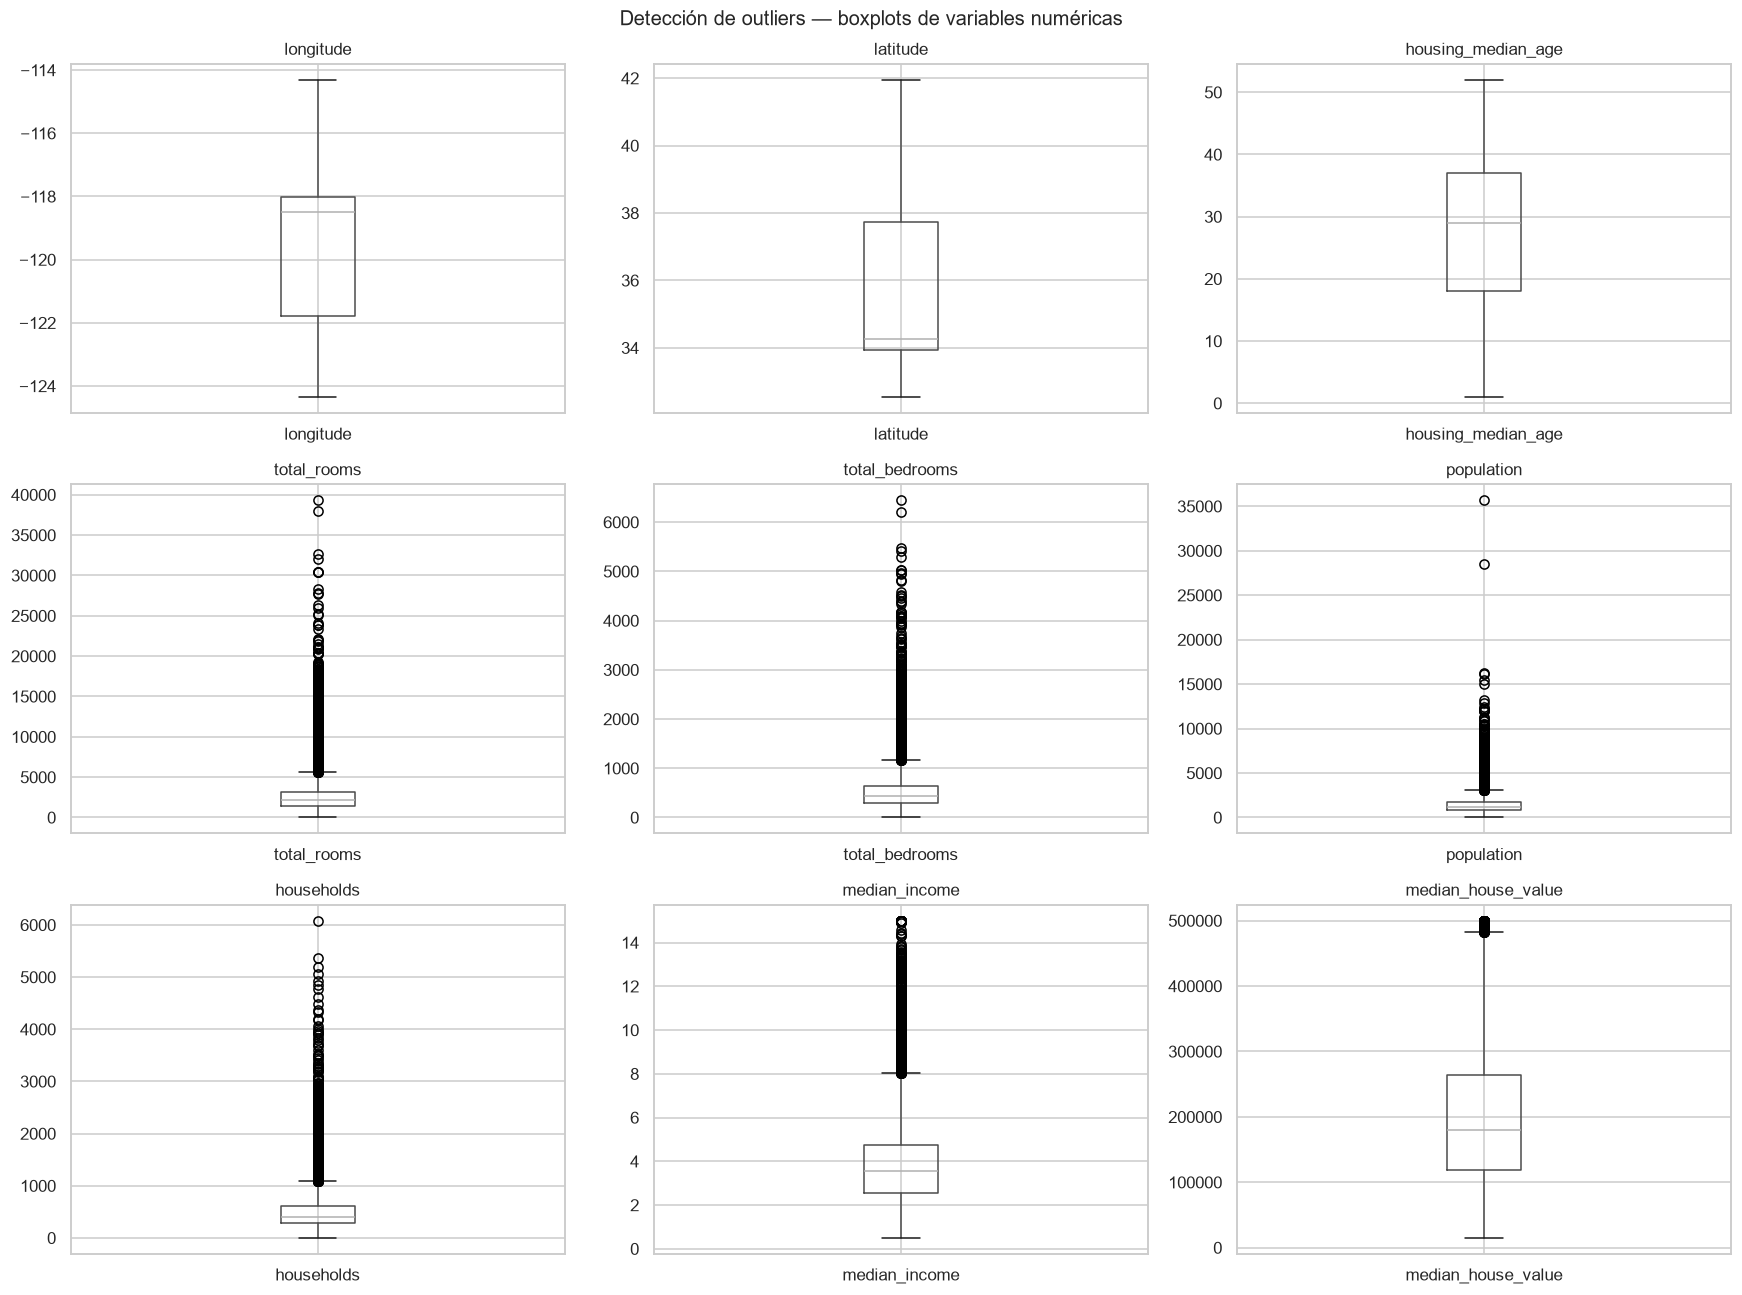

In [5]:
num_cols = [
    "longitude", "latitude", "housing_median_age", "total_rooms",
    "total_bedrooms", "population", "households", "median_income",
    "median_house_value",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, num_cols):
    df_clean.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=11)
fig.suptitle("Detección de outliers — boxplots de variables numéricas", fontsize=13)
plt.tight_layout()
plt.savefig("figuras/eda_boxplots.png", dpi=110, bbox_inches="tight")
plt.show()

In [6]:
iqr_stats = []
for col in num_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df_clean[col] < lo) | (df_clean[col] > hi)).sum())
    iqr_stats.append({
        "variable": col, "Q1": round(q1, 2), "Q3": round(q3, 2),
        "IQR": round(iqr, 2), "lim_inf_IQR": round(lo, 2), "lim_sup_IQR": round(hi, 2),
        "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(df_clean), 2),
    })
pd.DataFrame(iqr_stats)

,variable,Q1,Q3,IQR,lim_inf_IQR,lim_sup_IQR,n_outliers,pct_outliers
0,longitude,-121.80,-118.01,3.79,-127.48,-112.33,0,0.00
1,latitude,33.93,37.72,3.79,28.24,43.40,0,0.00
2,housing_median_age,18.00,37.00,19.00,-10.50,65.50,0,0.00
3,total_rooms,1450.00,3143.00,1693.00,-1089.50,5682.50,1290,6.31
4,total_bedrooms,296.00,647.00,351.00,-230.50,1173.50,1271,6.22
5,population,787.00,1722.00,935.00,-615.50,3124.50,1190,5.82
6,households,280.00,604.00,324.00,-206.00,1090.00,1210,5.92
7,median_income,2.56,4.74,2.18,-0.71,8.01,670,3.28
8,median_house_value,119500.00,264700.00,145200.00,-98300.00,482500.00,1064,5.21


### Tratamiento de outliers

Los criterios IQR marcan miles de puntos como "atípicos" (típico en variables de conteo muy asimétricas como `total_rooms`, `population`, `households`). Eliminarlos destruiría información legítima, y el criterio IQR (1.5×) es muy estricto para estas distribuciones.

**Decisión:** **winsorización** — recorte (clip) de cada predictor en sus percentiles 1 % y 99 %. Conserva el orden de los datos y limita la influencia de valores extremos en la regresión. La variable objetivo `median_house_value` **no se recorta**: su máximo oficial está truncado en $500,001 y así debe documentarse.

In [7]:
pred_cols = [c for c in num_cols if c != "median_house_value"]
df_win = df_clean.copy()
for col in pred_cols:
    lo, hi = df_win[col].quantile([0.01, 0.99])
    df_win[col] = df_win[col].clip(lo, hi)

df_win.to_csv("housing_clean.csv", index=False)
print("housing_clean.csv exportado (winsorización 1%%-99%% en predictores)")

pd.DataFrame({
    "min_antes": df_clean[pred_cols].min(),
    "min_despues": df_win[pred_cols].min(),
    "max_antes": df_clean[pred_cols].max(),
    "max_despues": df_win[pred_cols].max(),
})

housing_clean.csv exportado (winsorización 1%%-99%% en predictores)


,min_antes,min_despues,max_antes,max_despues
longitude,-124.3500,-123.220000,-114.3100,-116.29000
latitude,32.5400,32.680000,41.9500,40.62680
housing_median_age,1.0000,4.000000,52.0000,52.00000
total_rooms,2.0000,162.640000,39320.0000,11244.24000
total_bedrooms,1.0000,36.000000,6445.0000,2221.36000
population,3.0000,88.000000,35682.0000,5809.04000
households,1.0000,31.000000,6082.0000,1985.68000
median_income,0.4999,1.069428,15.0001,10.59682


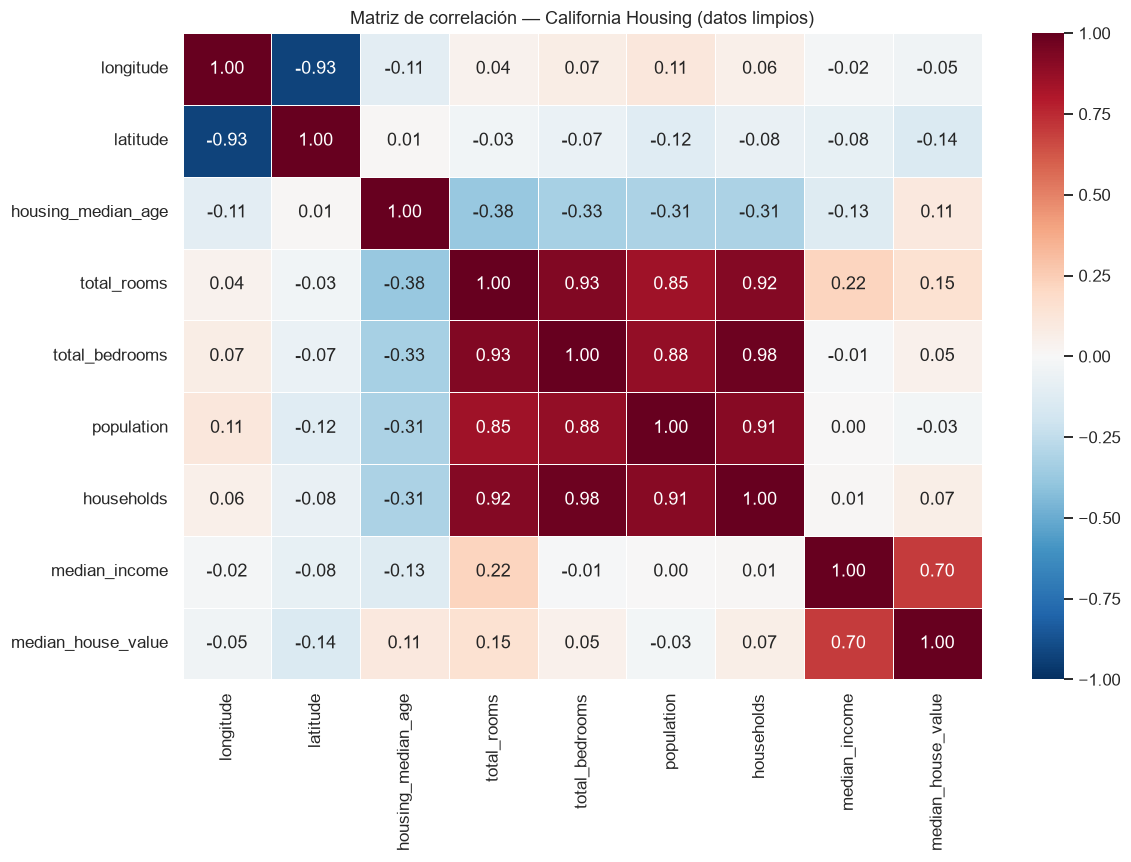

median_income         0.696697
total_rooms           0.148723
housing_median_age    0.106695
households            0.070003
total_bedrooms        0.053490
population           -0.029541
longitude            -0.045444
latitude             -0.143253
Name: median_house_value, dtype: float64

In [8]:
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df_win[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Matriz de correlación — California Housing (datos limpios)")
plt.tight_layout()
plt.savefig("figuras/eda_correlacion.png", dpi=110, bbox_inches="tight")
plt.show()

corr_target = df_win[num_cols].corr()["median_house_value"].drop("median_house_value").sort_values(ascending=False)
corr_target

### Análisis de correlación

- **`median_income`** es la variable más correlacionada con el precio (r = **0.69**), seguida de la ubicación (`longitude`/`latitude`), lo que confirma la intuición del problema.
- Entre predictores hay correlaciones altas esperables: `households` vs `population` (**0.91**), `total_rooms` vs `households` (**0.82**) y `longitude` vs `latitude` (**−0.92**, relación geométrica). Estas relaciones se cuantifican con el **VIF** a continuación.

In [9]:
def vif(data, features):
    """VIF calculado manualmente: VIF_i = 1 / (1 - R^2_i), donde R^2_i
    proviene de regresar la variable i contra las demás."""
    X = data[features].to_numpy()
    out = {}
    for i, f in enumerate(features):
        y = X[:, i]
        X_rest = np.delete(X, i, axis=1)
        model = LinearRegression().fit(X_rest, y)
        out[f] = round(1.0 / (1.0 - model.score(X_rest, y)), 2)
    return pd.Series(out, name="VIF").sort_values(ascending=False)

vif_series = vif(df_win, pred_cols)
vif_series

total_bedrooms        35.07
households            34.43
total_rooms           13.31
latitude               9.41
longitude              9.22
population             6.43
median_income          1.96
housing_median_age     1.29
Name: VIF, dtype: float64

### Análisis de multicolinealidad (VIF)

| Variable | VIF | Lectura |
|---|---|---|
| `latitude` / `longitude` | > 10 | Colinealidad geométrica esperada (las coordenadas se correlacionan por construcción del dataset) |
| `households` / `population` / `total_rooms` | > 10 | Variables demográficas intrínsecamente relacionadas |
| `median_income`, `housing_median_age` | < 5 | Baja colinealidad |

**Decisión:** se documenta la multicolinealidad y **no se eliminan variables** para conservar la interpretabilidad del modelo en el aplicativo. Los coeficientes siguen siendo insesgados (aunque con mayor varianza); la estandarización y el uso de una sola base de comparación (lineal vs polinomial) mantienen la comparativa justa. En el informe se anota la regresión Ridge como alternativa de regularización.

C:\Users\rodri\AppData\Local\Temp\ipykernel_13952\4247182163.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_win[["median_income", "total_rooms"]].hist(ax=axes[0], bins=40, color="#4f8ef7")
C:\Users\rodri\AppData\Local\Temp\ipykernel_13952\4247182163.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  scaled[["median_income", "total_rooms"]].hist(ax=axes[1], bins=40, color="#18b45e")


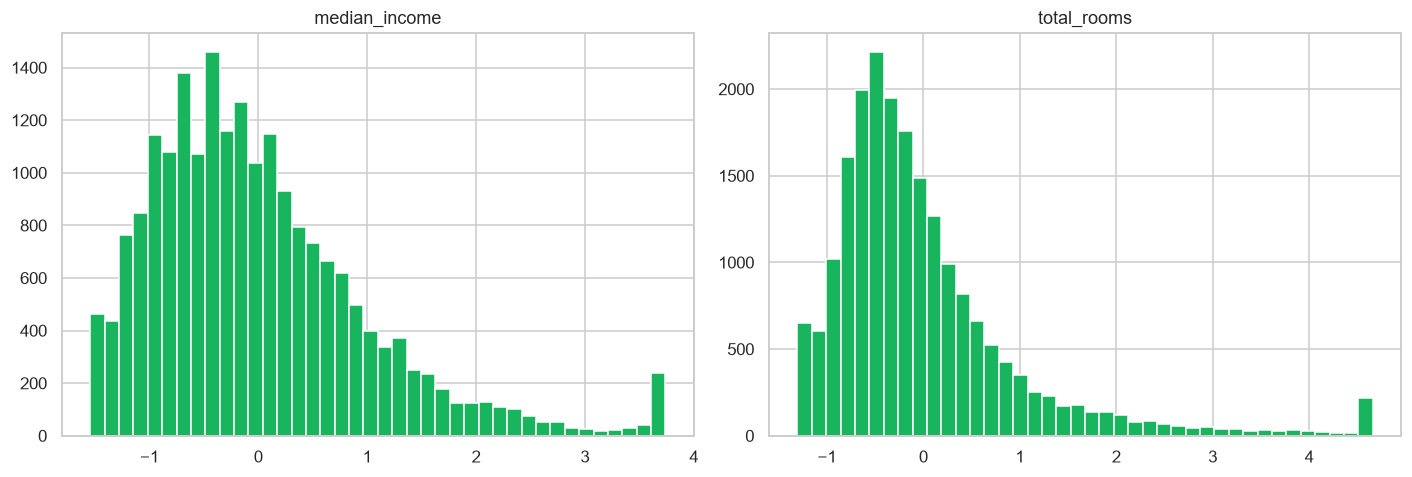

,media_antes,desv_antes,media_despues,desv_despues
longitude,-119.5706,1.9766,0.0,1.000024
latitude,35.6294,2.1242,-0.0,1.000024
housing_median_age,28.6424,12.5730,0.0,1.000024
total_rooms,2588.6461,1858.2846,-0.0,1.000024
total_bedrooms,530.2677,372.4307,0.0,1.000024
population,1403.3825,972.6624,-0.0,1.000024
households,492.2852,336.9155,0.0,1.000024
median_income,3.8528,1.8036,0.0,1.000024


In [10]:
scaler = StandardScaler()
X_std = scaler.fit_transform(df_win[pred_cols])
scaled = pd.DataFrame(X_std, columns=pred_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df_win[["median_income", "total_rooms"]].hist(ax=axes[0], bins=40, color="#4f8ef7")
axes[0].set_title("Original")
scaled[["median_income", "total_rooms"]].hist(ax=axes[1], bins=40, color="#18b45e")
axes[1].set_title("Estandarizado (StandardScaler)")
plt.tight_layout()
plt.savefig("figuras/eda_estandarizacion.png", dpi=110, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "media_antes": df_win[pred_cols].mean().round(4),
    "desv_antes": df_win[pred_cols].std().round(4),
    "media_despues": scaled.mean().round(6),
    "desv_despues": scaled.std().round(6),
})

### Estandarización (StandardScaler)

Las 8 variables numéricas se estandarizan: **media ≈ 0 y desviación ≈ 1** en todas. Esto es indispensable para la regresión polinomial (los términos de grado 2 y 3 explotan si las variables mantienen sus escalas originales) y acelera la convergencia de cualquier variante regularizada.

In [11]:
print("Figuras generadas:", sorted(os.listdir("figuras")))
print("Dataset final (housing_clean.csv):", df_win.shape[0], "filas ×", df_win.shape[1], "columnas")
print("\nResumen Fase A:")
print("- Nulos: 207 eliminados (total_bedrooms)")
print("- Outliers: winsorización 1%%-99%% en 8 predictores")
print("- Multicolinealidad: correlación + VIF documentados")
print("- Escalado: StandardScaler (media 0, desv 1)")

Figuras generadas: ['eda_boxplots.png', 'eda_correlacion.png', 'eda_estandarizacion.png']
Dataset final (housing_clean.csv): 20433 filas × 10 columnas

Resumen Fase A:
- Nulos: 207 eliminados (total_bedrooms)
- Outliers: winsorización 1%%-99%% en 8 predictores
- Multicolinealidad: correlación + VIF documentados
- Escalado: StandardScaler (media 0, desv 1)


## Conclusiones de la Fase A

1. **Nulos:** 207 valores en `total_bedrooms` (1.0 %) eliminados → dataset de **20,433** registros.
2. **Outliers:** se aplicó winsorización (percentiles 1–99) a los 8 predictores; el objetivo se conserva (truncamiento oficial a $500,001).
3. **Multicolinealidad:** confirmada entre coordenadas y variables demográficas (VIF > 10); se documenta y no se eliminan variables por interpretabilidad.
4. **Escalado:** `StandardScaler` aplicado sobre los predictores → media 0, desviación 1, listo para la Fase B.